In [1]:
from google.colab import files
uploaded = files.upload()


Saving Superstore.csv to Superstore.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# making charts look a bit nicer
sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
print("Mean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Mode Sales:", df["Sales"].mode()[0])
print("Standard Deviation of Sales:", df["Sales"].std())

df.describe()

Mean Sales: 230.7690594591837
Median Sales: 54.489999999999995
Mode Sales: 12.96
Standard Deviation of Sales: 626.6518748388047


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,2017-06
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,2016-10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,2016-10


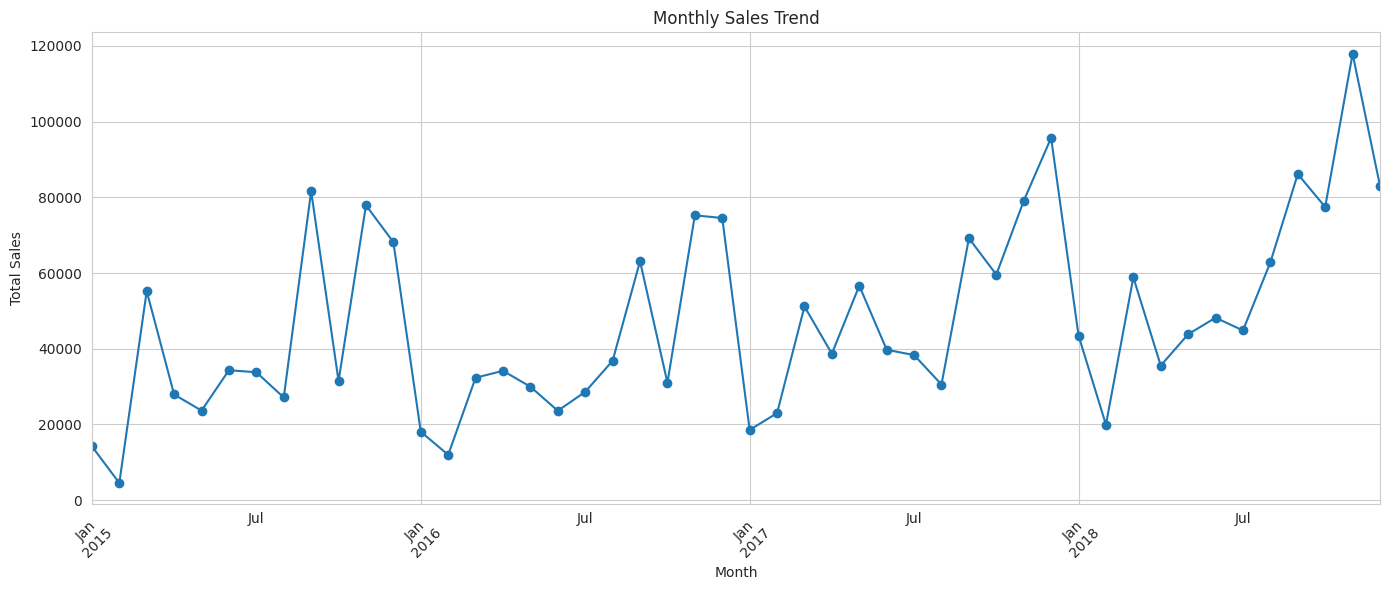

In [15]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

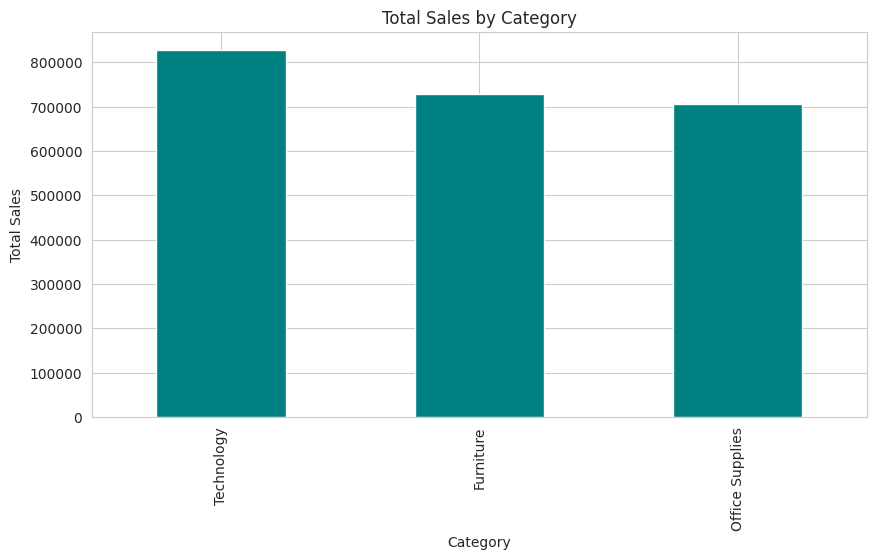

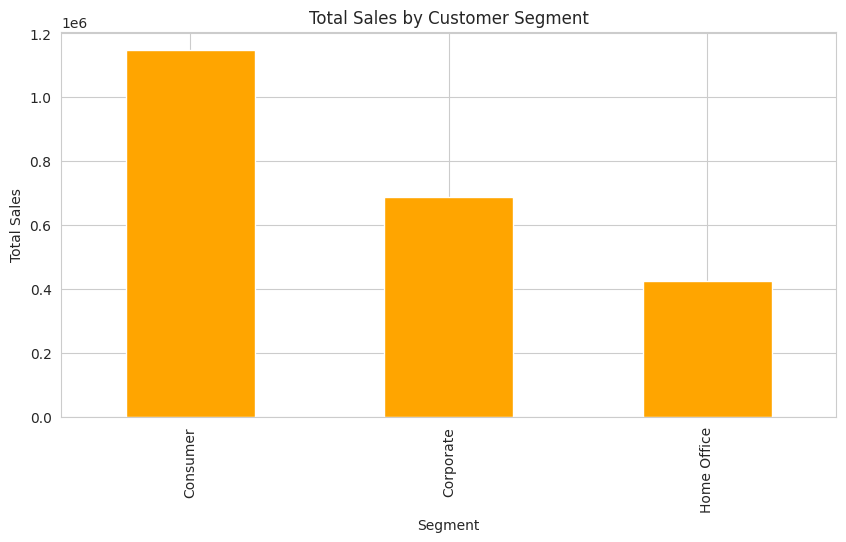

In [16]:
plt.figure(figsize=(10,5))
df.groupby("Category")["Sales"].sum().sort_values(ascending=False).plot(kind="bar", color="teal")
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.show()

plt.figure(figsize=(10,5))
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).plot(kind="bar", color="orange")
plt.title("Total Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.show()

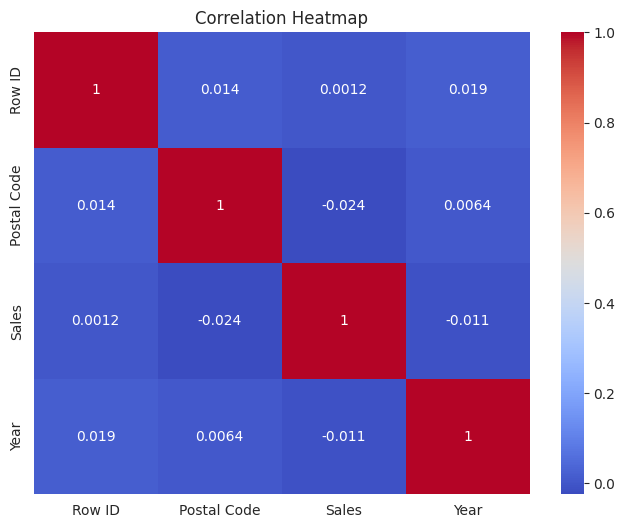

In [17]:
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

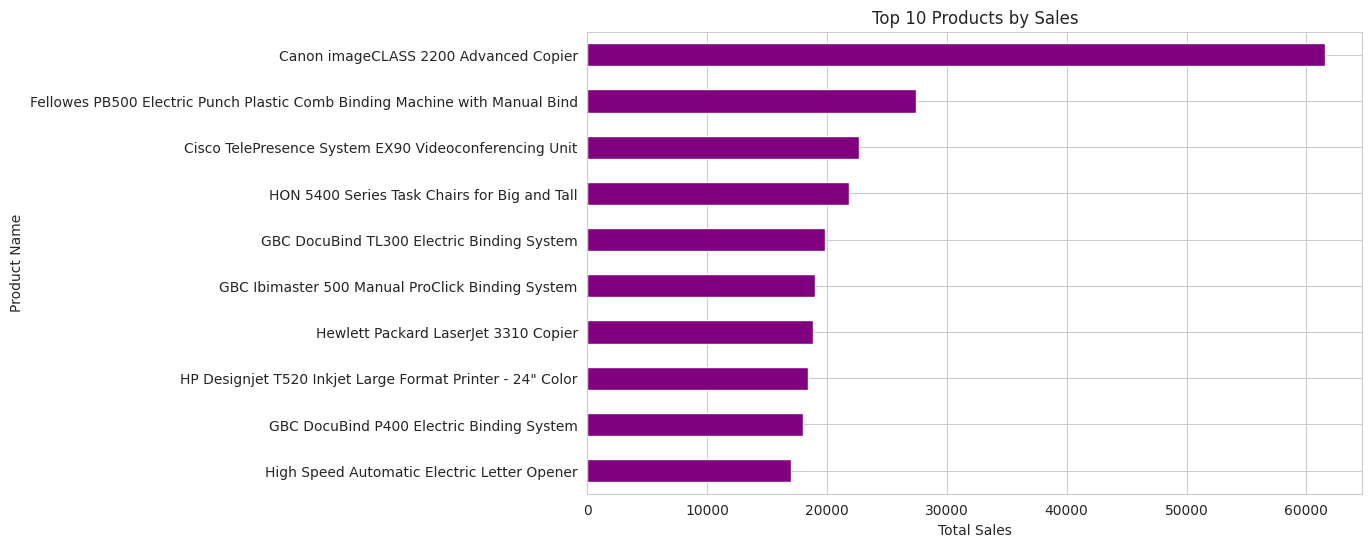

In [18]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_products.plot(kind="barh", color="purple")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()
plt.show()

## Insights and Recommendations

1. Sales follow a clear seasonal pattern, dipping every January-February and peaking around November-December each year, with the highest spike occurring in late 2018. The business should increase inventory and marketing spend ahead of the holiday season.

2. Technology is the top-performing category by revenue, closely followed by Furniture and Office Supplies — these three categories are fairly balanced and all deserve continued investment.

3. Consumer is by far the most valuable customer segment, generating over 1.1 million in sales versus roughly 700,000 for Corporate and 430,000 for Home Office. Marketing efforts should prioritize retaining and growing the Consumer base.

4. The average sale value (230.77) is much higher than the median (54.49), showing that a small number of large orders are skewing the overall average upward — most transactions are actually modest in size.

5. A single product, the Canon imageCLASS 2200 Advanced Copier, generated more than double the sales of any other product, showing how a few high-ticket items can disproportionately drive revenue. Stock availability for such items should be carefully monitored.

6. The dataset required minimal cleaning, with only the Postal Code column having a small number of missing values (11 out of 9,800 rows), which don't affect the core sales analysis.